# Baseline Models
---

In this notebook, I'm going to produce some predictions using naive models and SARIMA. Such prediction will serve as a baseline for comparison with more complex modeling approaches.

In [1]:
import sys
sys.path.append('../src')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scoring import walk_forward_cv, compute_metrics

In [3]:
prices = pd.read_csv('../data/raw/prices_IT_2015_2024.csv', index_col=0, parse_dates=True).squeeze()
prices.index = pd.to_datetime(prices.index, utc=True)
print(f"{prices.size} hours")
print(f"{prices.index.min()} -> {prices.index.max()}")
prices = prices.astype('float16')

78793 hours
2015-01-04 23:00:00+00:00 -> 2023-12-31 23:00:00+00:00


## Naive Models
---

I defined two naive models as the very lowest effort approach. They predict future prices will be equal to last week and last day prices, respectively. Any model that can't sistematically beat these two is to be considered useless. $$x_{\mathrm{s},t} = x_{t-168}$$ $$x_{\mathrm{d},t} = x_{t-24}$$

To evaluate model performance I will use a walk-forward cross-validation and consider three different measures of error:
- `MAE`: Mean Absolute Error
- `RMSE`: Root Mean Squared Error
- `MAPE`: Mean Absolute Percentage Error

Each measure describes a slighlty different type of error. `MAE` weights any error the same. `RMSE` is more strict towards greater errors. Finally, `MAPE` considers the error relative to the true value of prices, so the same error is less significant when prices are high.

In [4]:
from baseline_models import naive_daily, naive_seasonal

In [5]:
metrics_seasonal, preds_seasonal, true_seasonal, _ = walk_forward_cv(prices, naive_seasonal, test_size=24)

metrics_daily, preds_daily, true_daily, _ = walk_forward_cv(prices, naive_daily, test_size=24)

In [6]:
print("Weekly naive:\n", metrics_seasonal.mean())
print("Daily naive:\n", metrics_daily.mean())

Weekly naive:
 MAE     15.367295
RMSE    18.272895
MAPE    22.328512
dtype: float64
Daily naive:
 MAE     12.225558
RMSE    15.161453
MAPE    21.108468
dtype: float64


### Exponential average
---
A more sophisticated model can be obtained by considering **all** previous days-of-week, and weighting them exponentially less the farther they are from the time we are predicting. $$x_{\mathrm{es},t} = \frac{x_{t-168}\lambda^{-1} + x_{t-2\cdot168}\lambda^{-2} + x_{t-3\cdot168}\lambda^{-3}+...}{\lambda^{-1}+\lambda^{-2}+\lambda^{-3}+...}=\frac{\sum_{i=1}^{N}{x_{t-iT}\lambda^{-i}}}{\sum_{i=1}^{N}{\lambda^{-i}}}$$
The optimal value of $\lambda$ is the one that performs best at CV.

In [7]:
from baseline_models import exp_seasonal

In [8]:
metrics = []
lambdas = np.logspace(0,1,20)
for x in lambdas:
    metric, _, _, _ = walk_forward_cv(prices, exp_seasonal, 168, lamb=x)
    metrics.append(metric)

In [9]:
average_metrics = [x.mean() for x in metrics]

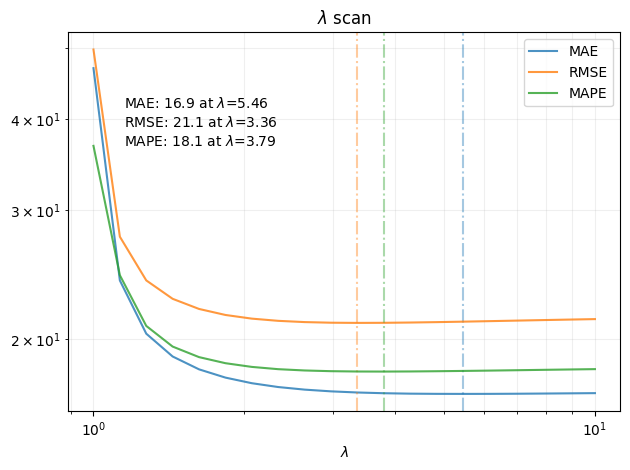

In [10]:
maes = pd.Series([x['MAE'] for x in average_metrics], index=lambdas)
maes.plot(alpha=0.8, label="MAE")
plt.axvline(maes.index[maes.argmin()], color='C0', ls='-.', alpha=0.4)
plt.annotate(f"MAE: {maes.min():.1f} at $\\lambda$={maes.index[maes.argmin()]:.2f}", xy=(0.1,0.8), xycoords="axes fraction")
rmses = pd.Series([x['RMSE'] for x in average_metrics], index=lambdas)
rmses.plot(alpha=0.8, label="RMSE")
plt.axvline(rmses.index[rmses.argmin()], color='C1', ls='-.', alpha=0.4)
plt.annotate(f"RMSE: {rmses.min():.1f} at $\\lambda$={rmses.index[rmses.argmin()]:.2f}", xy=(0.1,0.75), xycoords="axes fraction")
mapes = pd.Series([x['MAPE'] for x in average_metrics], index=lambdas)
mapes.plot(alpha=0.8, label="MAPE")
plt.axvline(mapes.index[mapes.argmin()], color='C2', ls='-.', alpha=0.4)
plt.annotate(f"MAPE: {mapes.min():.1f} at $\\lambda$={mapes.index[mapes.argmin()]:.2f}", xy=(0.1,0.7), xycoords="axes fraction")
plt.loglog()
plt.xlabel("$\\lambda$")
plt.grid(alpha=0.2, which='both')
plt.title("$\\lambda$ scan")
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/03_lambda_scan.png')

In [11]:
metrics_seasonal_exp, preds_seasonal_exp, true_seasonal_exp, _ = walk_forward_cv(prices, exp_seasonal, test_size=24, lamb=3.36)
print("Weekly exponential:\n", metrics_seasonal_exp.mean())

Weekly exponential:>>>>>>>>>>>>>>>>]
 MAE     12.077746
RMSE    14.748993
MAPE    21.193142
dtype: float64


In [12]:
from matplotlib.patches import Patch

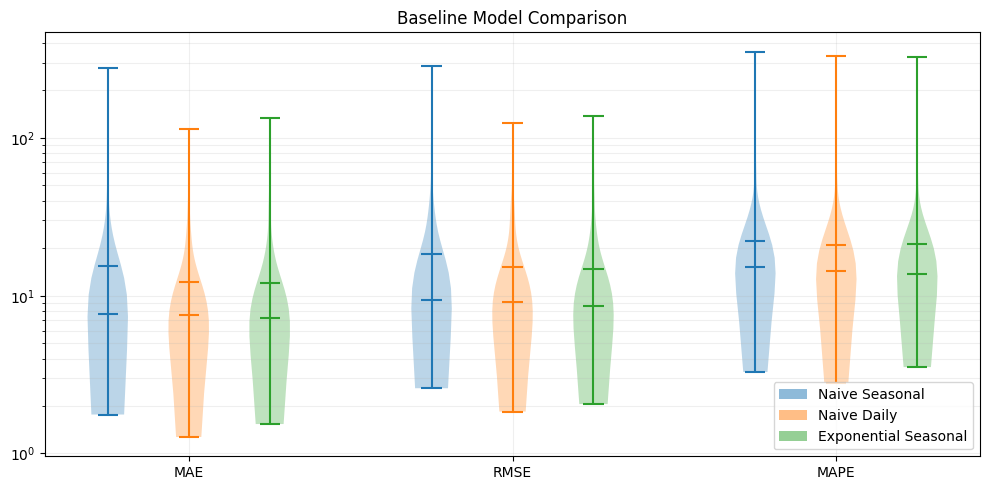

In [13]:
fig, ax = plt.subplots(figsize=(10,5))

ax.grid(which='both', alpha=0.2)
ax.violinplot(metrics_seasonal, positions=[1,5,9], showmeans=True, showmedians=True)
ax.violinplot(metrics_daily, positions=[2,6,10], showmeans=True, showmedians=True)
ax.violinplot(metrics_seasonal_exp, positions=[3,7,11], showmeans=True, showmedians=True)
legend_elems = [Patch(facecolor='C0', alpha=0.5, label="Naive Seasonal"),
                Patch(facecolor='C1', alpha=0.5, label="Naive Daily"),
                Patch(facecolor='C2', alpha=0.5, label="Exponential Seasonal")]
ax.set_xticks([2, 6, 10], labels=["MAE", "RMSE", "MAPE"])
ax.set_yscale('log')
ax.legend(handles=legend_elems)
ax.set_title("Baseline Model Comparison")
plt.tight_layout()
plt.savefig('../data/processed/03_baseline_comparison.png')

## SARIMA Model
---

In [14]:
from baseline_models import sarima_forecast
from statsmodels.tsa.statespace.sarimax import SARIMAXResults

The two code cells below needs to be executed only once, then the fitted model and timeseries are saved in `data/processed` to be loaded when needed.

In [15]:
# metrics_sarima, preds_sarima, true_sarima, fitted_sarima = walk_forward_cv(
#     prices, sarima_forecast,
#     test_size=24,
#     step = 24 * 30
# )

In [16]:
# metrics_sarima.to_csv('../data/processed/metrics_sarima.csv')
# preds_sarima.to_csv('../data/processed/preds_sarima.csv')
# true_sarima.to_csv('../data/processed/true_sarima.csv')
# fitted_sarima.save(fname='../data/fitted_sarima')

In [17]:
fitted_sarima = SARIMAXResults.load('../data/fitted_sarima')

In [18]:
metrics_sarima = pd.read_csv('../data/processed/metrics_sarima.csv', index_col=0, parse_dates=True)
preds_sarima = pd.read_csv('../data/processed/preds_sarima.csv', index_col=0, parse_dates=True).squeeze()
true_sarima = pd.read_csv('../data/processed/true_sarima.csv', index_col=0, parse_dates=True)

for x in [metrics_sarima, preds_sarima, true_sarima]:
    x.index = pd.to_datetime(x.index, utc=True)

In [19]:
print("SARIMA - foldwise metrics:")
print(metrics_sarima[['MAE', 'RMSE', 'MAPE']].describe())

SARIMA - foldwise metrics:
              MAE        RMSE        MAPE
count  107.000000  107.000000  107.000000
mean    12.087879   14.839206   13.346187
std     15.024945   18.064190   10.653493
min      1.026000    1.266000    2.075000
25%      3.674000    4.563000    6.424500
50%      6.881000    8.586000   10.118000
75%     12.195500   15.654500   17.083500
max     91.167000  110.415000   64.813000


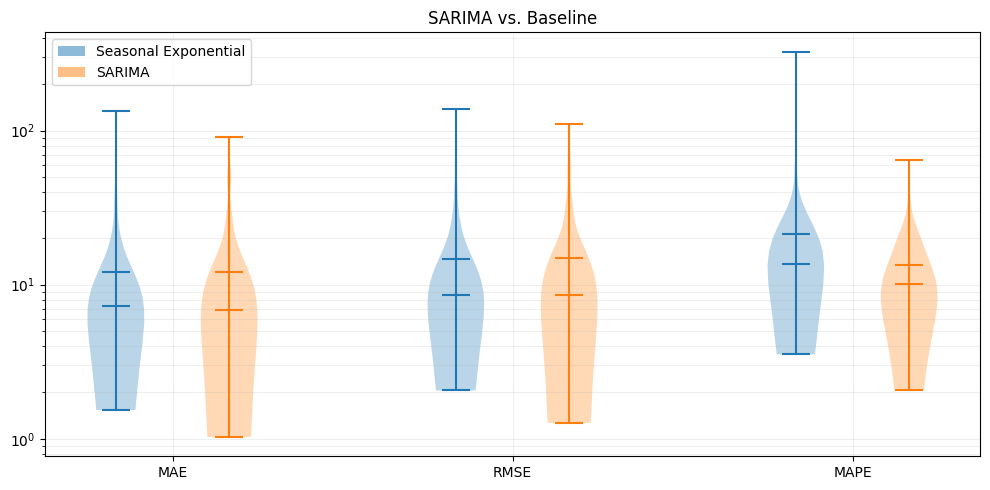

In [20]:
fig, ax = plt.subplots(figsize=(10,5))
ax.grid(which='both', alpha=0.2)
ax.violinplot(metrics_seasonal_exp, positions=[1,4,7], showmeans=True, showmedians=True)
ax.violinplot(metrics_sarima, positions=[2,5,8], showmeans=True, showmedians=True)
ax.set_xticks([1.5,4.5,7.5], labels=["MAE", "RMSE", "MAPE"])
ax.set_yscale('log')
legend_elems = [Patch(facecolor='C0', alpha=0.5, label="Seasonal Exponential"),
                Patch(facecolor='C1', alpha=0.5, label="SARIMA")]
ax.legend(handles=legend_elems)
ax.set_title("SARIMA vs. Baseline")
plt.tight_layout()
plt.savefig('../data/processed/03_SARIMA_results.png')

## Visual comparison
---

In [21]:
covid_lockdown = '2020-03-01'
metrics_seasonal_pre_covid = compute_metrics(true_seasonal.loc[:covid_lockdown].to_numpy(), preds_seasonal.loc[:covid_lockdown].to_numpy())
metrics_daily_pre_covid = compute_metrics(true_daily.loc[:covid_lockdown].to_numpy(), preds_daily.loc[:covid_lockdown].to_numpy())
print("Weekly naive before CoViD:\t", metrics_daily_pre_covid)
print("Daily naive before CoViD:\t", metrics_daily_pre_covid)
metrics_seasonal_post_covid = compute_metrics(true_seasonal.loc[covid_lockdown:].to_numpy(), preds_seasonal.loc[covid_lockdown:].to_numpy())
metrics_daily_post_covid = compute_metrics(true_daily.loc[covid_lockdown:].to_numpy(), preds_daily.loc[covid_lockdown:].to_numpy())
print("Weekly naive after CoViD:\t", metrics_daily_post_covid)
print("Daily naive after CoViD:\t", metrics_daily_post_covid)
print("Weekly exp before CoViD:\t", metrics_seasonal_exp.loc[:covid_lockdown].mean().to_dict())
print("Weekly exp after CoViD:\t\t", metrics_seasonal_exp.loc[covid_lockdown:].mean().to_dict())

Weekly naive before CoViD:	 {'MAE': np.float64(6.461), 'RMSE': np.float64(8.774), 'MAPE': np.float64(17.554)}
Daily naive before CoViD:	 {'MAE': np.float64(6.461), 'RMSE': np.float64(8.774), 'MAPE': np.float64(17.554)}
Weekly naive after CoViD:	 {'MAE': np.float64(19.594), 'RMSE': np.float64(33.581), 'MAPE': np.float64(25.806)}
Daily naive after CoViD:	 {'MAE': np.float64(19.594), 'RMSE': np.float64(33.581), 'MAPE': np.float64(25.806)}
Weekly exp before CoViD:	 {'MAE': 6.161879377431907, 'RMSE': 7.469653696498055, 'MAPE': 17.166657587548638}
Weekly exp after CoViD:		 {'MAE': 19.679635, 'RMSE': 24.102945, 'MAPE': 26.367174999999996}


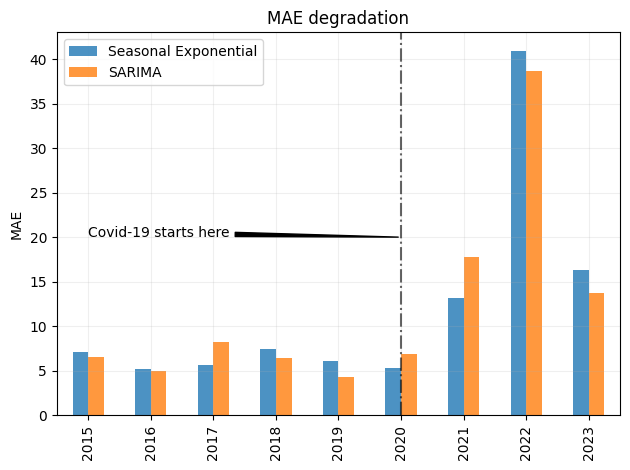

In [22]:
fig, ax = plt.subplots()
yearly_MAE = []
yearly_MAE.append(metrics_seasonal_exp.MAE.groupby(by=metrics_seasonal_exp.index.year).mean())
yearly_MAE.append(metrics_sarima.MAE.groupby(by=metrics_sarima.index.year).mean())
yearly_MAE = pd.DataFrame(yearly_MAE, index=["Seasonal Exponential", "SARIMA"]).T
yearly_MAE.plot(ax=ax, kind="bar", alpha=0.8)
ax.grid(alpha=0.2)
ax.axvline(5, c='black', alpha=0.6, ls='-.')
ax.annotate("Covid-19 starts here", [5,20], [0,20], arrowprops=dict(facecolor='black', arrowstyle='wedge'))
plt.title("MAE degradation")
plt.xlabel("")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig('../data/processed/03_performance_degradation.png')

In [23]:
print(f"SARIMA:\t\t{metrics_sarima["MAPE"].loc[covid_lockdown:].mean() / metrics_sarima["MAPE"].loc[:covid_lockdown].mean() - 1:.1%} worse prediction after lockdown")
print(f"Daily naive:\t{metrics_daily_post_covid["MAPE"] / metrics_daily_pre_covid["MAPE"] - 1:.1%} worse prediction after lockdown")
print(f"Weekly naive:\t{metrics_seasonal_post_covid["MAPE"] / metrics_seasonal_pre_covid["MAPE"] - 1:.1%} worse prediction after lockdown")

SARIMA:		23.3% worse prediction after lockdown
Daily naive:	47.0% worse prediction after lockdown
Weekly naive:	73.0% worse prediction after lockdown


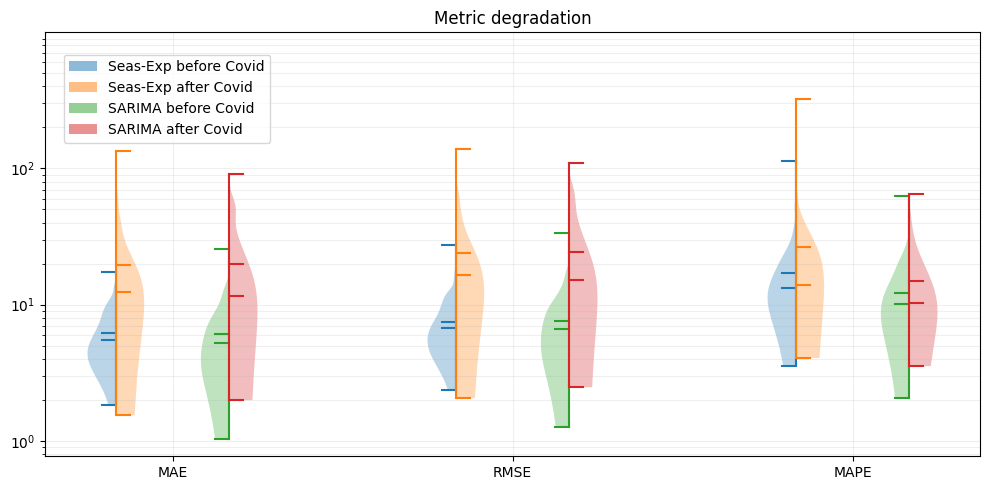

In [24]:
fig, ax = plt.subplots(figsize=(10,5))
ax.grid(which='both', alpha=0.2)
ax.violinplot(metrics_seasonal_exp.loc[:covid_lockdown], positions=[1,4,7], showmeans=True, showmedians=True, side='low')
ax.violinplot(metrics_seasonal_exp.loc[covid_lockdown:], positions=[1,4,7], showmeans=True, showmedians=True, side='high')
ax.violinplot(metrics_sarima.loc[:covid_lockdown], positions=[2,5,8], showmeans=True, showmedians=True, side='low')
ax.violinplot(metrics_sarima.loc[covid_lockdown:], positions=[2,5,8], showmeans=True, showmedians=True, side='high')
ax.set_xticks([1.5,4.5,7.5], labels=["MAE", "RMSE", "MAPE"])
ax.set_yscale('log')
ax.set_ylim(top=1e3-1)
legend_elems = [Patch(facecolor='C0', alpha=0.5, label="Seas-Exp before Covid"),
                Patch(facecolor='C1', alpha=0.5, label="Seas-Exp after Covid"),
                Patch(facecolor='C2', alpha=0.5, label="SARIMA before Covid"),
                Patch(facecolor='C3', alpha=0.5, label="SARIMA after Covid"),
                ]
ax.legend(handles=legend_elems, loc=[0.02,0.74])
ax.set_title("Metric degradation")
plt.tight_layout()
plt.savefig('../data/processed/03_metric_degradation.png')